In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import xml.etree.ElementTree as ET
from pathlib import Path
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. REFERENCE DATABASE (JCPDS-15-0861)
# ---------------------------------------------------------
# Standard peak positions (2θ degrees) and reference intensities (I0)
# from the JCPDS Sb2Se3 crystallographic database

reference_card = {
    '110': {'2theta': 10.676, 'I0': 8.0},
    '020': {'2theta': 15.029, 'I0': 25.0},
    '200': {'2theta': 15.211, 'I0': 6.0},
    '120': {'2theta': 16.874, 'I0': 55.0},
    '220': {'2theta': 21.446, 'I0': 10.0},
    '101': {'2theta': 23.643, 'I0': 12.0},
    '130': {'2theta': 23.901, 'I0': 30.0},
    '310': {'2theta': 24.152, 'I0': 16.0},
    '021': {'2theta': 27.023, 'I0': 12.0},
    '230': {'2theta': 27.395, 'I0': 70.0},
    '211': {'2theta': 28.2, 'I0': 75.0},
    '040': {'2theta': 30.326, 'I0': 2.0},
    '400': {'2theta': 30.699, 'I0': 4.0},
    '221': {'2theta': 31.16, 'I0': 100.0},
    '301': {'2theta': 32.22, 'I0': 60.0},
    '330': {'2theta': 32.424, 'I0': 10.0},
    '311': {'2theta': 33.115, 'I0': 20.0},
    '240': {'2theta': 34.075, 'I0': 60.0},
    '420': {'2theta': 34.358, 'I0': 20.0},
    '321': {'2theta': 35.7, 'I0': 30.0},
    '041': {'2theta': 37.984, 'I0': 25.0},
    '340': {'2theta': 38.354, 'I0': 14.0},
    '430': {'2theta': 38.49, 'I0': 14.0},
    '141': {'2theta': 38.801, 'I0': 35.0},
    '411': {'2theta': 39.081, 'I0': 12.0},
    '510': {'2theta': 39.456, 'I0': 8.0},
    '331': {'2theta': 39.71, 'I0': 8.0},
    '250': {'2theta': 41.305, 'I0': 35.0},
    '520': {'2theta': 41.705, 'I0': 20.0},
    '440': {'2theta': 43.694, 'I0': 10.0},
    '431': {'2theta': 44.95, 'I0': 35.0},
    '501': {'2theta': 45.068, 'I0': 30.0},
    '530': {'2theta': 45.258, 'I0': 30.0},
    '151': {'2theta': 45.354, 'I0': 25.0},
    '002': {'2theta': 45.571, 'I0': 25.0},
    '060': {'2theta': 46.209, 'I0': 8.0},
    '600': {'2theta': 46.84, 'I0': 8.0},
    '160': {'2theta': 46.892, 'I0': 8.0},
    '610': {'2theta': 47.49, 'I0': 8.0},
    '212': {'2theta': 48.902, 'I0': 8.0},
    '620': {'2theta': 49.469, 'I0': 4.0},
    '441': {'2theta': 49.584, 'I0': 4.0},
    '540': {'2theta': 49.903, 'I0': 4.0},
    '351': {'2theta': 50.765, 'I0': 8.0},
    '531': {'2theta': 51.039, 'I0': 16.0},
    '061': {'2theta': 51.879, 'I0': 45.0},
    '360': {'2theta': 52.166, 'I0': 20.0},
    '322': {'2theta': 53.956, 'I0': 14.0},
    '621': {'2theta': 54.865, 'I0': 6.0},
    '710': {'2theta': 55.807, 'I0': 6.0},
    '142': {'2theta': 56.328, 'I0': 1.0},
    '412': {'2theta': 56.479, 'I0': 1.0},
    '640': {'2theta': 56.821, 'I0': 6.0},
    '270': {'2theta': 56.898, 'I0': 8.0},
    '720': {'2theta': 57.559, 'I0': 12.0},
    '242': {'2theta': 58.115, 'I0': 18.0},
    '422': {'2theta': 58.276, 'I0': 10.0},
    '370': {'2theta': 59.854, 'I0': 8.0},
    '171': {'2theta': 60.155, 'I0': 6.0},
}

print("Reference Database Loaded (JCPDS-15-0861)")
print(f"Number of reference peaks: {len(reference_card)}")

Reference Database Loaded (JCPDS-15-0861)
Number of reference peaks: 59


# XRD Spectrum Analysis

This notebook loads and displays the experimental XRD spectrum from the available .ASC file.

In [147]:
# Find the workspace root by searching for the 'data' folder from the current notebook working directory upward.
current_path = Path.cwd().resolve()
workspace_root = None
for parent in [current_path] + list(current_path.parents):
    if (parent / 'data' / 'XRD' / '2 Round').exists():
        workspace_root = parent
        break

if workspace_root is None:
    workspace_root = current_path
    print('Warning: Could not locate workspace root automatically; using current working directory.')

xrd_folder = workspace_root / 'data' / 'XRD' / '2 Round'
print(f'Searching for XRD data in: {xrd_folder}')

# Choose the exact ASC files you want to plot.
# If selected_files is empty, all ASC files in the folder will be loaded.
selected_files = [
    'Mo_room_25Se_400Sb_35Se.ASC',
    'Mo_400deg_25Se_400Sb_35Se.ASC',
    'Mo_400Sb_30Se.ASC',
    #'Mo_300Sb_35Se.ASC',
    #'Mo_200Sb_25Se.ASC',
    
]

if selected_files:
    xrd_files = [xrd_folder / filename for filename in selected_files]
else:
    xrd_files = sorted(xrd_folder.glob('*.ASC'))

spectra = []
for xrd_file in xrd_files:
    if xrd_file.exists():
        data = np.loadtxt(xrd_file)
        theta = data[:, 0]
        intensity = data[:, 1]
        spectra.append((xrd_file.name, theta, intensity))
        print(f'Loaded {xrd_file.name}: {len(theta)} points, 2θ range {theta.min():.2f}°–{theta.max():.2f}°')
    else:
        print(f'File not found: {xrd_file.name}')

if not spectra:
    print('No XRD spectra were loaded. Please verify the files exist in data/XRD/2 Round.')
else:
    print(f'Total spectra loaded: {len(spectra)}')

Searching for XRD data in: C:\Users\jp_ol\OneDrive\Ambiente de Trabalho\TESE\Data_Analysis\data\XRD\2 Round
Loaded Mo_room_25Se_400Sb_35Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Loaded Mo_400deg_25Se_400Sb_35Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Loaded Mo_400Sb_30Se.ASC: 13999 points, 2θ range 10.01°–80.00°
Total spectra loaded: 3


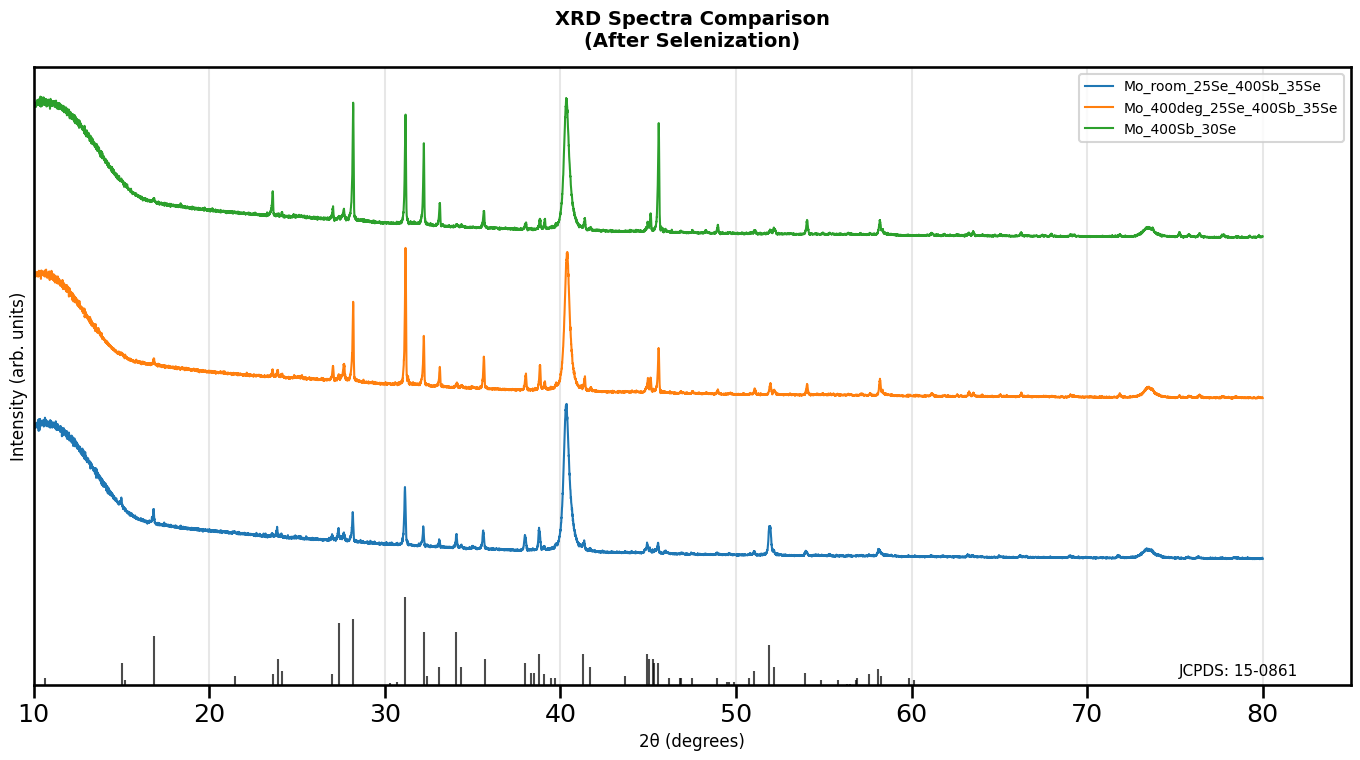

In [148]:
if spectra:
    fig, ax = plt.subplots(figsize=(14, 8))

    # -------------------------------
    # Reference pattern (JCPDS)
    # -------------------------------
    theta_2_ref = [ref_data['2theta'] for ref_data in reference_card.values()]
    intensity_ref = [ref_data['I0'] for ref_data in reference_card.values()]

    # Maximum intensity of all spectra
    max_intensity_all = max(intensity.max() for _, _, intensity in spectra)

    # ===== Adjustable parameters =====
    reference_height = max_intensity_all * 0.55   # Height of JCPDS bars
    gap = max_intensity_all * 0.20                # Gap between JCPDS and first spectrum
    offset_step = max_intensity_all * 1.0         # Gap between spectra
    # ================================

    # Normalize JCPDS intensities
    intensity_ref_normalized = (
        np.array(intensity_ref) /
        np.max(intensity_ref) *
        reference_height
    )

    # Offset of the first spectrum
    offset_exp = reference_height + gap

    colors = plt.cm.tab10.colors

    # -------------------------------
    # Plot JCPDS reference
    # -------------------------------
    baseline = 0

    ax.vlines(
        theta_2_ref,
        baseline,
        baseline + intensity_ref_normalized,
        colors='k',
        linewidth=1.5,
        alpha=0.7
    )

    # -------------------------------
    # Plot experimental spectra
    # -------------------------------
    for index, (name, theta, intensity) in enumerate(spectra):

        offset = offset_exp + index * offset_step

        ax.plot(
            theta,
            intensity + offset,
            color=colors[index % len(colors)],
            linewidth=1.5,
            label=name.replace(".ASC", "")
        )

    # JCPDS label
    ax.text(
        82,
        reference_height * 0.08,
        "JCPDS: 15-0861",
        ha="right",
        va="bottom",
        fontsize=11
    )

    # Axes
    ax.set_title(
        "XRD Spectra Comparison\n(After Selenization)",
        fontsize=14,
        weight="bold",
        pad=15
    )

    ax.set_xlabel("2θ (degrees)", fontsize=12)
    ax.set_ylabel("Intensity (arb. units)", fontsize=12)

    ax.set_xlim(10, 85)
    ax.set_ylim(bottom=0)

    ax.set_yticks([])
    ax.grid(True, axis='x', alpha=0.3)

    ax.legend(loc="upper right", fontsize=10, frameon=True)

    plt.tight_layout()
    plt.show()

else:
    print("No spectrum data available to plot.")

## TC Comparison

In [149]:
# ---------------------------------------------------------
# 2. HELPER FUNCTIONS FOR EXCEL DATA LOADING
# ---------------------------------------------------------

def parse_value_with_error(value_str):
    """
    Parse values in format "99.1234(8)" where (8) represents the error.
    Returns (value, error) tuple.
    
    Example:
    - "99.1234(8)" → (99.1234, 0.0008)
    - "100.5" → (100.5, 0.0)
    """
    value_str = str(value_str).strip().replace(',', '.')
    
    if '(' not in value_str:
        try:
            return float(value_str), 0.0
        except:
            return np.nan, np.nan

    try:
        parts = value_str.split('(')
        base_str = parts[0]
        error_str = parts[1].replace(')', '')
        
        base_val = float(base_str)
        error_int = int(error_str)
        
        # Calculate error magnitude based on decimal places
        if '.' in base_str:
            decimal_places = len(base_str.split('.')[1])
            factor = 10 ** (-decimal_places)
            error_val = error_int * factor
        else:
            error_val = float(error_int)
            
        return base_val, error_val
        
    except Exception as e:
        return np.nan, np.nan


def load_excel_data(file_path):
    """
    Load XRD data from Excel file.
    
    Supports Excel (.xlsx) and CSV files.
    Automatically identifies columns for:
    - Position (2Theta): column containing "Pos" and "2Th"
    - Intensity (Height): column containing "Height"
    - Database match: column containing "Matched by"
    
    Returns:
    - Tuple (DataFrame, col_pos, col_height, col_match) or (None, None, None, None) on error
    """
    print(f"\n--> Attempting to read: {file_path}")

    try:
        df = pd.read_excel(file_path)
        print("✓ Excel file loaded successfully")
    except Exception as e:
        print(f"⚠ Excel failed: {e}")
        print("  Attempting to read as CSV...")
        try:
            df = pd.read_csv(file_path, sep=';') 
            if df.shape[1] < 2:
                df = pd.read_csv(file_path, sep=',')
            print("✓ CSV file loaded successfully")
        except Exception as e2:
            print(f"✗ CRITICAL ERROR: Could not read the file. Details: {e2}")
            return None, None, None, None

    # Identify important columns
    try:
        col_pos = [c for c in df.columns if "Pos" in c and "2Th" in c][0]
        col_height = [c for c in df.columns if "Height" in c][0] 
        col_match = [c for c in df.columns if "Matched by" in c][0]
        print(f"✓ Identified columns: Pos='{col_pos}', Height='{col_height}', Match='{col_match}'")
    except IndexError:
        print("✗ ERROR: Required column names not found in file")
        print(f"   Available columns: {list(df.columns)}")
        return None, None, None, None

    # Parse position and height values with errors
    pos_vals, pos_errs = [], []
    height_vals, height_errs = [], []

    for x in df[col_pos]:
        v, e = parse_value_with_error(x)
        pos_vals.append(v)
        pos_errs.append(e)
        
    for x in df[col_height]:
        v, e = parse_value_with_error(x)
        height_vals.append(v)
        height_errs.append(e)

    # Update dataframe with parsed values
    df[col_pos] = pos_vals
    df['Pos_Error'] = pos_errs
    df[col_height] = height_vals
    df['Height_Error'] = height_errs 

    # Remove rows with missing values
    df = df.dropna(subset=[col_pos, col_height])
    
    return df, col_pos, col_height, col_match


# Load Excel files
print("\n--- LOADING EXPERIMENTAL DATA FROM EXCEL ---")

# Look for Excel files in the same folder as ASC files (data/XRD/2 Round)
excel_folder = xrd_folder  # Use the same folder as ASC files
excel_files = sorted(excel_folder.glob('*.xlsx'))

if not excel_files:
    print(f"⚠ No Excel files found in {excel_folder}")
    print("  Files will be loaded manually if specified")
    excel_files = []

experimental_data = {}
excel_metadata = {}

if excel_files:
    for excel_file in excel_files:
        filename = excel_file.name.replace('.xlsx', '')
        df, col_pos, col_height, col_match = load_excel_data(str(excel_file))
        
        if df is not None:
            experimental_data[filename] = df
            excel_metadata[filename] = {
                'col_pos': col_pos,
                'col_height': col_height,
                'col_match': col_match
            }
            print(f"  ✓ Loaded {len(df)} rows from {filename}")

if experimental_data:
    print(f"\n✓ Successfully loaded {len(experimental_data)} Excel file(s)")
else:
    print("\n⚠ No Excel files were loaded. Please specify an Excel file path in the next cell.")


--- LOADING EXPERIMENTAL DATA FROM EXCEL ---

--> Attempting to read: C:\Users\jp_ol\OneDrive\Ambiente de Trabalho\TESE\Data_Analysis\data\XRD\2 Round\Mo_200Sb_25Se.xlsx
✓ Excel file loaded successfully
✓ Identified columns: Pos='Pos. [°2Th.]', Height='Height [cts]', Match='Matched by'
  ✓ Loaded 35 rows from Mo_200Sb_25Se

--> Attempting to read: C:\Users\jp_ol\OneDrive\Ambiente de Trabalho\TESE\Data_Analysis\data\XRD\2 Round\Mo_300Sb_35Se.xlsx
✓ Excel file loaded successfully
✓ Identified columns: Pos='Pos. [°2Th.]', Height='Height [cts]', Match='Matched by'
  ✓ Loaded 44 rows from Mo_300Sb_35Se

--> Attempting to read: C:\Users\jp_ol\OneDrive\Ambiente de Trabalho\TESE\Data_Analysis\data\XRD\2 Round\Mo_400deg_25Se_400Sb.xlsx
✓ Excel file loaded successfully
✓ Identified columns: Pos='Pos. [°2Th.]', Height='Height [cts]', Match='Matched by'
  ✓ Loaded 6 rows from Mo_400deg_25Se_400Sb

--> Attempting to read: C:\Users\jp_ol\OneDrive\Ambiente de Trabalho\TESE\Data_Analysis\data\XRD\2 R

In [150]:
def match_peaks_from_excel(df, reference_card, col_pos, col_height, col_match, tolerance=0.1):
    """
    Match peaks from Excel data with reference crystallographic planes.
    
    Process:
    1. Filter for peaks matching JCPDS "00-015-0861"
    2. For each reference peak, find closest experimental peak within tolerance
    3. Return matched peaks and their intensities
    
    Parameters:
    - df: DataFrame with experimental data
    - reference_card: Dictionary with reference peak data
    - col_pos: Column name for 2Theta positions
    - col_height: Column name for intensities
    - col_match: Column name for JCPDS database match
    - tolerance: Tolerance window in degrees for peak matching
    
    Returns:
    - Dictionary with matched peak data
    """
    
    # Filter for peaks matching JCPDS-15-0861 (Sb2Se3)
    df_filtered = df[df[col_match].astype(str).str.contains("00-015-0861", na=False)].copy()
    
    if df_filtered.empty:
        print("  ⚠ WARNING: No peaks matching '00-015-0861' found.")
        return None
    
    print(f"  Filtered peaks matching JCPDS-15-0861: {len(df_filtered)}")
    
    matched_peaks = {
        'hkl': [],
        '2theta_ref': [],
        'intensity_ref': [],
        'intensity_exp': [],
        'intensity_err': []
    }
    
    # Match each reference peak with closest experimental peak
    for hkl, ref_data in reference_card.items():
        ref_2theta = ref_data['2theta']
        ref_intensity = ref_data['I0']
        
        # Find peaks within tolerance window
        mask = (df_filtered[col_pos] >= ref_2theta - tolerance) & \
               (df_filtered[col_pos] <= ref_2theta + tolerance)
        
        matches = df_filtered[mask]
        
        if not matches.empty:
            # Take the peak with maximum intensity
            idx_max = matches[col_height].idxmax()
            exp_intensity = matches.loc[idx_max, col_height]
            exp_error = matches.loc[idx_max, 'Height_Error']
            
            matched_peaks['hkl'].append(hkl)
            matched_peaks['2theta_ref'].append(ref_2theta)
            matched_peaks['intensity_ref'].append(ref_intensity)
            matched_peaks['intensity_exp'].append(exp_intensity)
            matched_peaks['intensity_err'].append(exp_error)
    
    if len(matched_peaks['hkl']) == 0:
        print("  ✗ ERROR: No matching peaks found after filtering!")
        return None
    
    return matched_peaks

# Match peaks for all experimental datasets
print("\n--- MATCHING PEAKS WITH REFERENCE DATA ---")
all_matched_peaks = {}

for filename, exp_df in experimental_data.items():
    print(f"\n{filename}:")
    
    metadata = excel_metadata[filename]
    matched = match_peaks_from_excel(
        exp_df, 
        reference_card,
        metadata['col_pos'],
        metadata['col_height'],
        metadata['col_match'],
        tolerance=0.1
    )
    
    if matched is not None:
        all_matched_peaks[filename] = matched
        print(f"  ✓ Matched peaks: {len(matched['hkl'])}")
        
        # Show first few matches
        for i in range(min(5, len(matched['hkl']))):
            hkl = matched['hkl'][i]
            exp_int = matched['intensity_exp'][i]
            exp_err = matched['intensity_err'][i]
            ref_int = matched['intensity_ref'][i]
            print(f"    {hkl}: exp={exp_int:.1f}±{exp_err:.2f}, ref={ref_int:.1f}")


--- MATCHING PEAKS WITH REFERENCE DATA ---

Mo_200Sb_25Se:
  Filtered peaks matching JCPDS-15-0861: 25
  ✓ Matched peaks: 22
    021: exp=141.0±28.00, ref=12.0
    230: exp=377.0±58.00, ref=70.0
    211: exp=2306.0±36.00, ref=75.0
    221: exp=3104.0±39.00, ref=100.0
    301: exp=1475.0±40.00, ref=60.0

Mo_300Sb_35Se:
  Filtered peaks matching JCPDS-15-0861: 28
  ✓ Matched peaks: 28
    120: exp=221.3±0.00, ref=55.0
    101: exp=510.0±32.00, ref=12.0
    310: exp=720.0±20.00, ref=16.0
    021: exp=530.0±24.00, ref=12.0
    230: exp=350.0±22.00, ref=70.0

Mo_400deg_25Se_400Sb:
  ⚠ WARNING: No peaks matching '00-015-0861' found.

Mo_400deg_25Se_400Sb_35Se:
  Filtered peaks matching JCPDS-15-0861: 31
  ✓ Matched peaks: 32
    120: exp=302.0±0.00, ref=55.0
    101: exp=330.0±26.00, ref=12.0
    130: exp=375.0±29.00, ref=30.0
    310: exp=144.0±23.00, ref=16.0
    021: exp=901.0±36.00, ref=12.0

Mo_400Sb:
  ⚠ WARNING: No peaks matching '00-015-0861' found.

Mo_400Sb_30Se:
  Filtered peaks 

In [151]:
def calculate_texture_coefficients_with_errors(matched_peaks):
    """
    Calculate Texture Coefficients (TC) from matched peaks with error propagation.
    
    Process:
    1. Normalize experimental intensities: (I_exp / max) × 100
    2. Calculate intensity ratios: I_exp_norm / I_ref
    3. Find average denominator (normalization factor R)
    4. Compute TC: ratio / R
    5. Propagate errors through calculation
    
    This normalization ensures:
    - TC = 1.0 for isotropic (random) crystal orientation
    - TC > 1.0 for preferred orientations
    - TC < 1.0 for suppressed orientations
    
    Returns:
    - Dictionary with TC values, errors, and statistics
    """
    
    hkl_labels = matched_peaks['hkl']
    I_exp_raw = np.array(matched_peaks['intensity_exp'])
    I_exp_err_raw = np.array(matched_peaks['intensity_err'])
    I_std_raw = np.array(matched_peaks['intensity_ref'])
    
    N = len(I_exp_raw)
    
    if N == 0:
        print("ERROR: No matching peaks found!")
        return None
    
    # Step 1: Normalize to max intensity (× 100)
    max_val = np.max(I_exp_raw)
    if max_val > 0:
        I_exp_norm = (I_exp_raw / max_val) * 100
        # Error propagation for normalization
        I_exp_norm_err = (I_exp_err_raw / max_val) * 100
    else:
        I_exp_norm = I_exp_raw
        I_exp_norm_err = I_exp_err_raw
    
    # Step 2: Calculate intensity ratios
    ratios = I_exp_norm / I_std_raw
    
    # Error propagation for ratio: δ(A/B) = (A/B) * sqrt((δA/A)² + (δB/B)²)
    ratio_errors = ratios * np.sqrt((I_exp_norm_err / I_exp_norm)**2)
    ratio_errors = np.nan_to_num(ratio_errors, nan=0.0)  # Handle division by zero
    
    # Step 3: Calculate average denominator (normalization factor)
    average_denominator = np.average(ratios)
    
    if average_denominator == 0:
        print("ERROR: Denominator is zero!")
        return None
    
    # Step 4: Calculate TC values
    TC_values = ratios / average_denominator
    
    # Error in TC: δTC = (1/R) * δ(ratio)
    TC_errors = ratio_errors / average_denominator
    
    result = {
        'hkl': hkl_labels,
        'TC': TC_values,
        'TC_errors': TC_errors,
        'I_exp_raw': I_exp_raw,
        'I_exp_norm': I_exp_norm,
        'I_std': I_std_raw,
        'ratios': ratios,
        'average_denominator': average_denominator,
        'num_peaks': N
    }
    
    return result

# Calculate TC for all datasets
print("\n--- CALCULATING TEXTURE COEFFICIENTS ---")
all_TC_results = {}

for filename, matched_peaks in all_matched_peaks.items():
    print(f"\n{filename}:")
    tc_result = calculate_texture_coefficients_with_errors(matched_peaks)
    
    if tc_result is not None:
        all_TC_results[filename] = tc_result
        print(f"  ✓ Matched peaks: {tc_result['num_peaks']}")
        print(f"  Normalization factor (R): {tc_result['average_denominator']:.4f}")
        print(f"  TC range: {tc_result['TC'].min():.4f} - {tc_result['TC'].max():.4f}")
        print(f"  Mean TC: {tc_result['TC'].mean():.4f}")
        print(f"  Std Dev: {tc_result['TC'].std():.4f}")
        
        # Show top 3 preferred planes
        top_indices = np.argsort(tc_result['TC'])[-3:][::-1]
        print(f"  Top 3 preferred planes:")
        for idx in top_indices:
            tc = tc_result['TC'][idx]
            err = tc_result['TC_errors'][idx]
            print(f"    {tc_result['hkl'][idx]}: TC = {tc:.4f} ± {err:.4f}")


--- CALCULATING TEXTURE COEFFICIENTS ---

Mo_200Sb_25Se:
  ✓ Matched peaks: 22
  Normalization factor (R): 0.5907
  TC range: 0.0709 - 4.1058
  Mean TC: 1.0000
  Std Dev: 0.8387
  Top 3 preferred planes:
    002: TC = 4.1058 ± 0.0545
    422: TC = 1.9907 ± 0.0600
    221: TC = 1.6929 ± 0.0213

Mo_300Sb_35Se:
  ✓ Matched peaks: 28
  Normalization factor (R): 0.4700
  TC range: 0.1225 - 2.4181
  Mean TC: 1.0000
  Std Dev: 0.6951
  Top 3 preferred planes:
    422: TC = 2.4181 ± 0.0457
    002: TC = 2.3157 ± 0.0292
    221: TC = 2.1275 ± 0.0140

Mo_400deg_25Se_400Sb_35Se:
  ✓ Matched peaks: 32
  Normalization factor (R): 0.4023
  TC range: 0.1146 - 3.3301
  Mean TC: 1.0000
  Std Dev: 0.8287
  Top 3 preferred planes:
    002: TC = 3.3301 ± 0.0338
    422: TC = 2.5299 ± 0.1342
    221: TC = 2.4859 ± 0.0146

Mo_400Sb_30Se:
  ✓ Matched peaks: 26
  Normalization factor (R): 0.6885
  TC range: 0.0310 - 5.5413
  Mean TC: 1.0000
  Std Dev: 1.1228
  Top 3 preferred planes:
    002: TC = 5.5413 ± 0


--- GENERATING VISUALIZATIONS ---


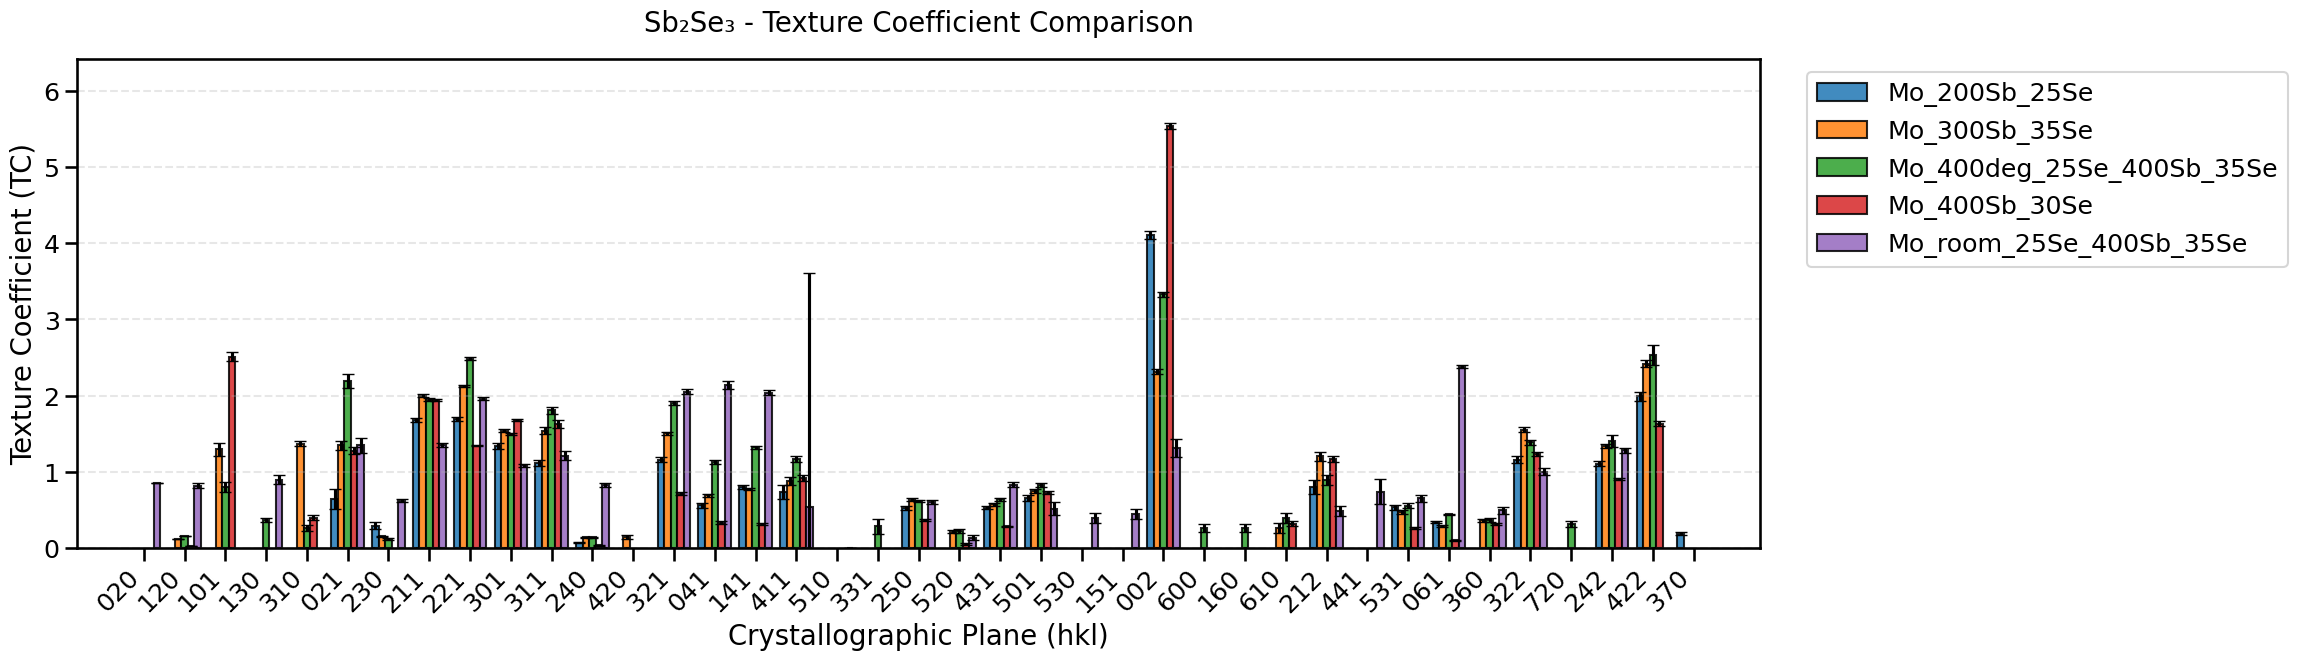

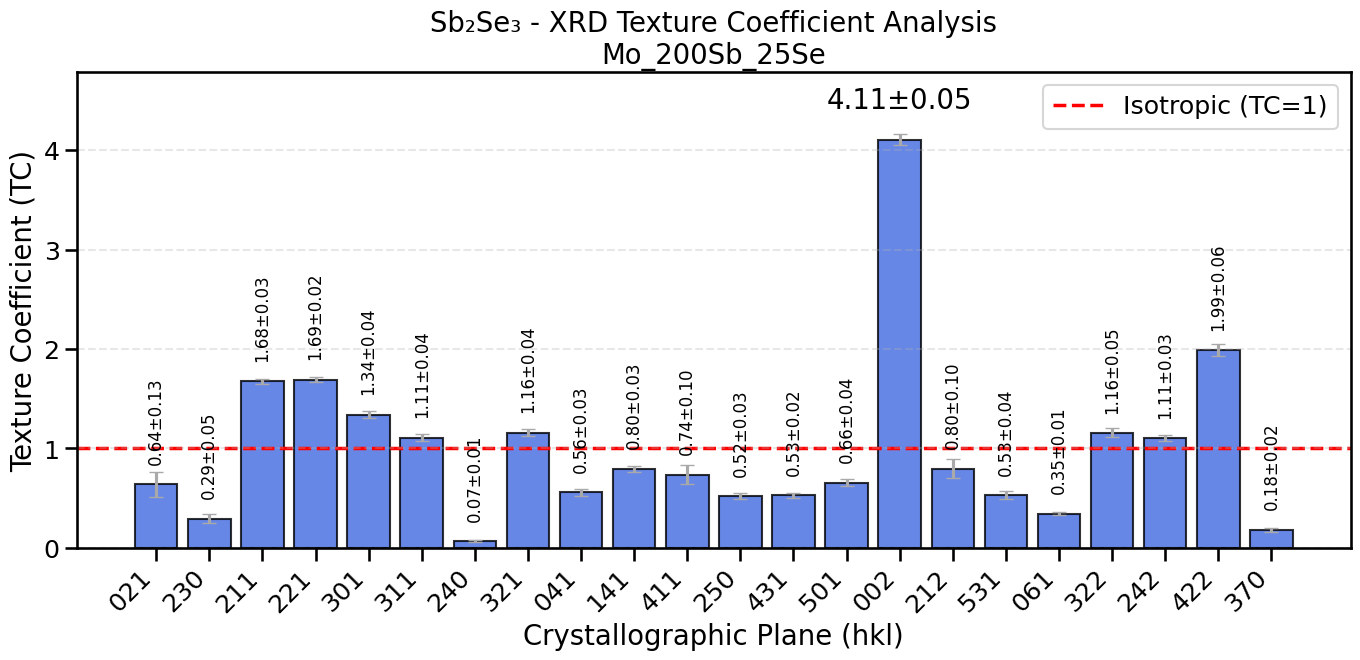

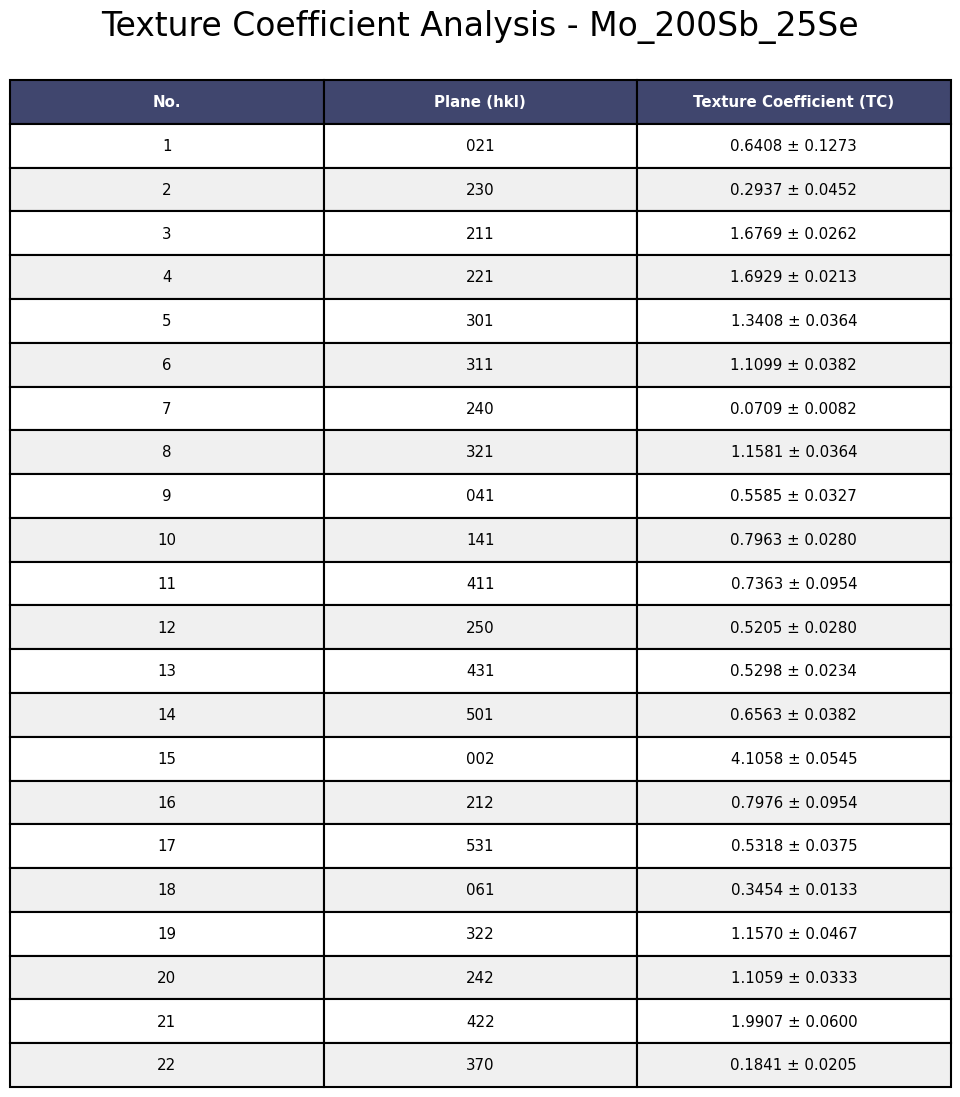

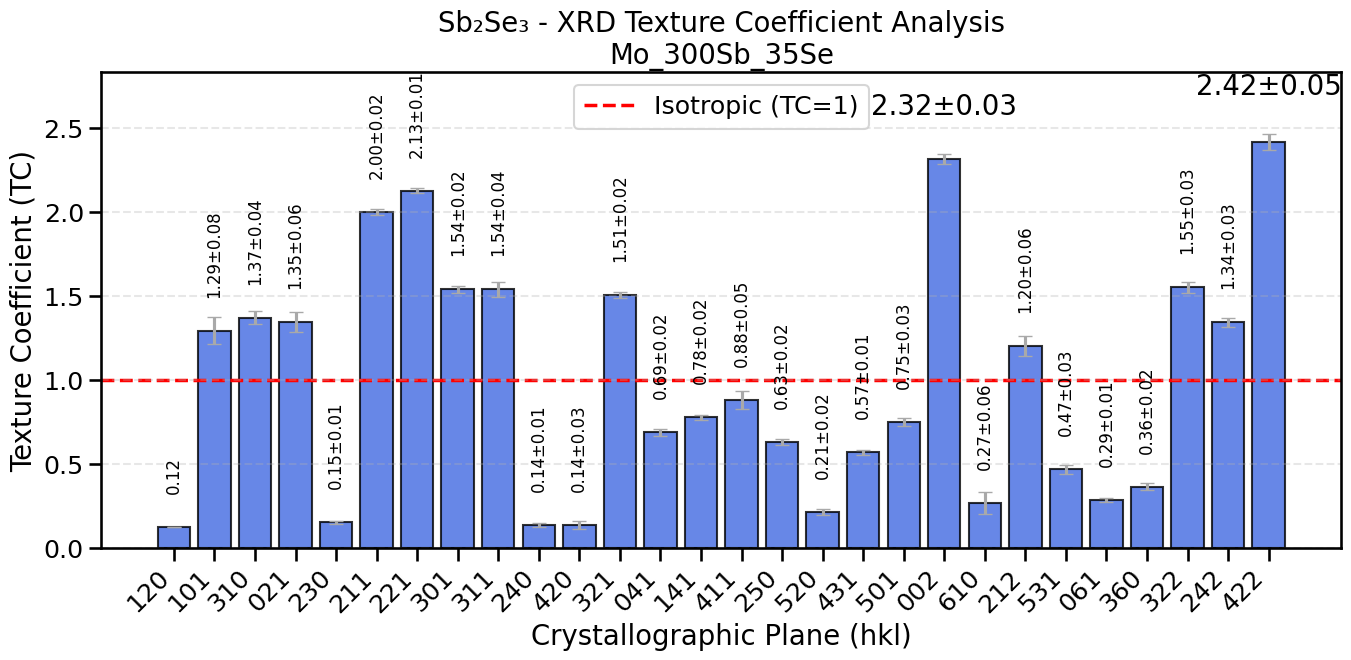

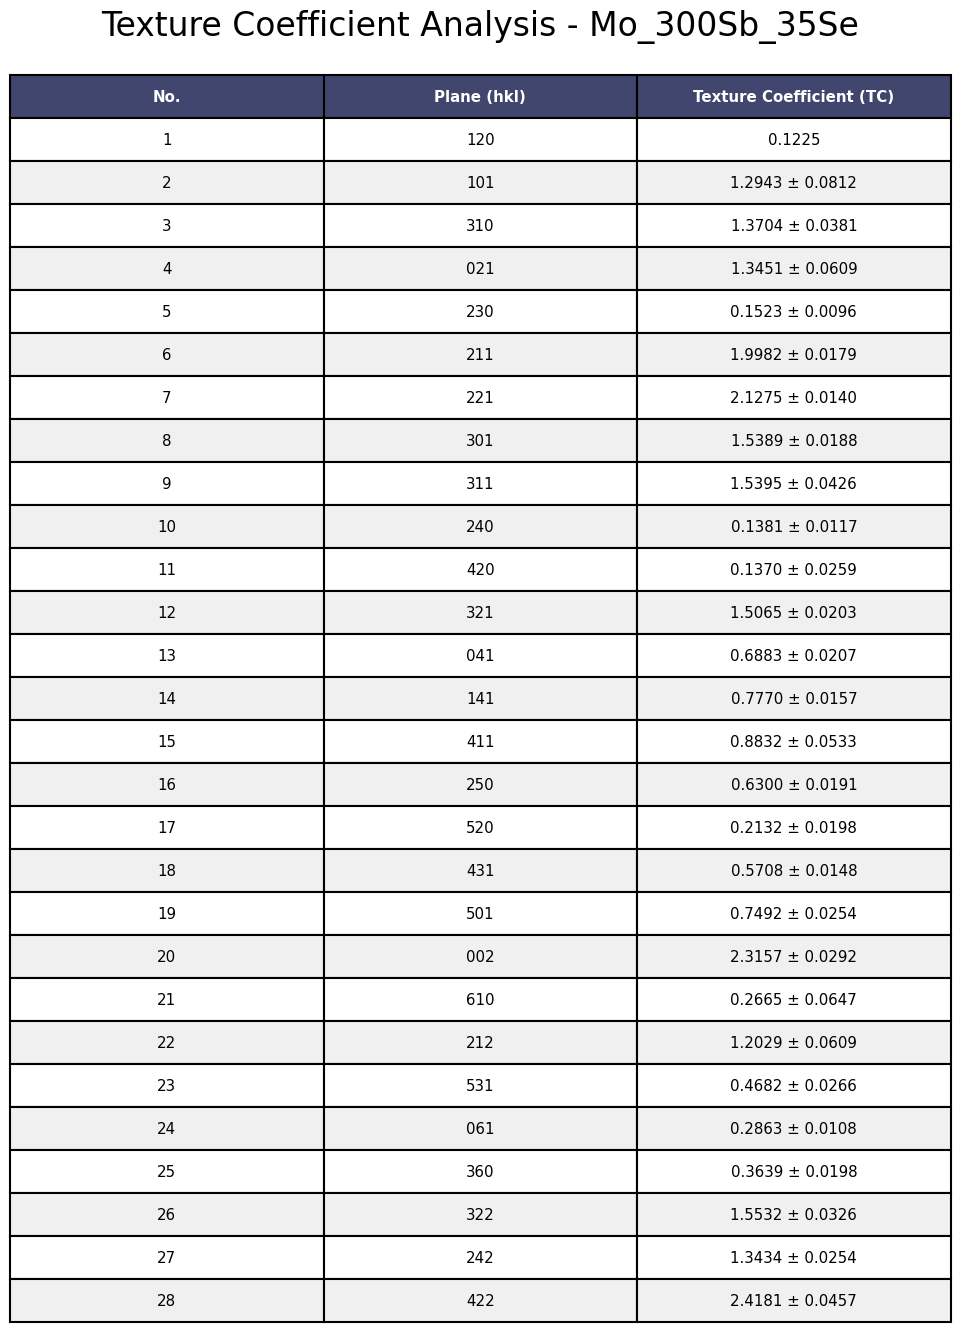

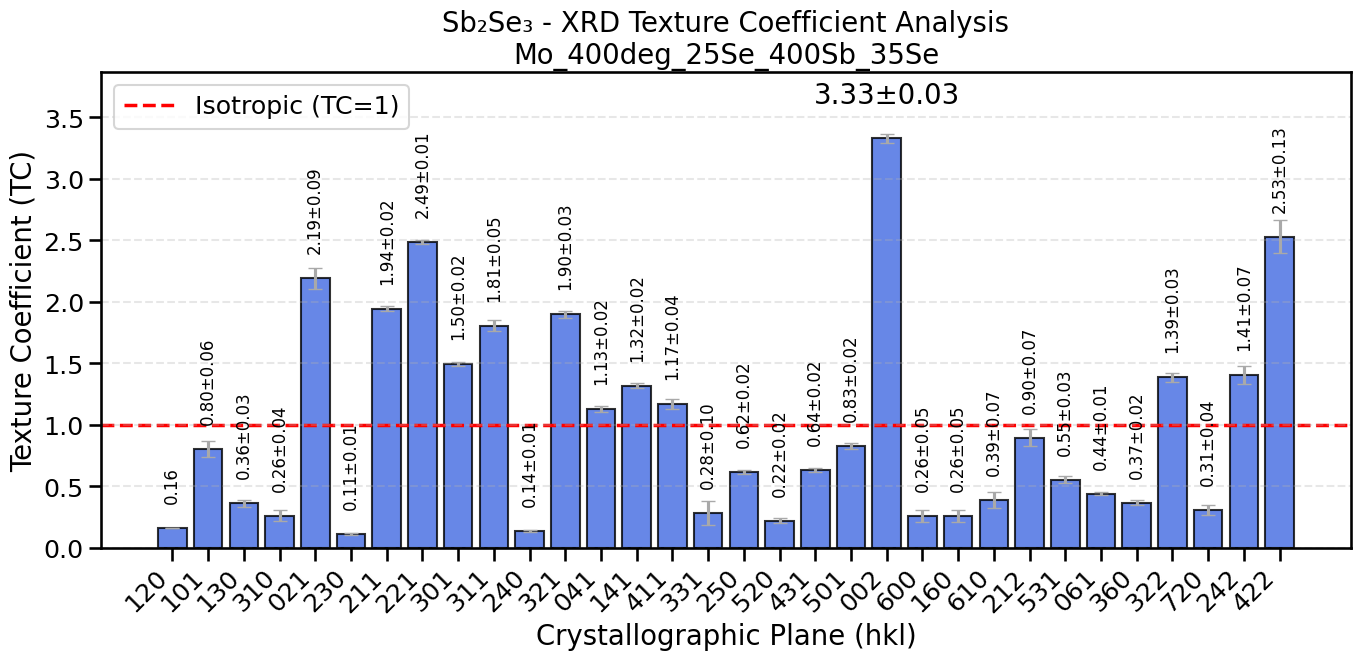

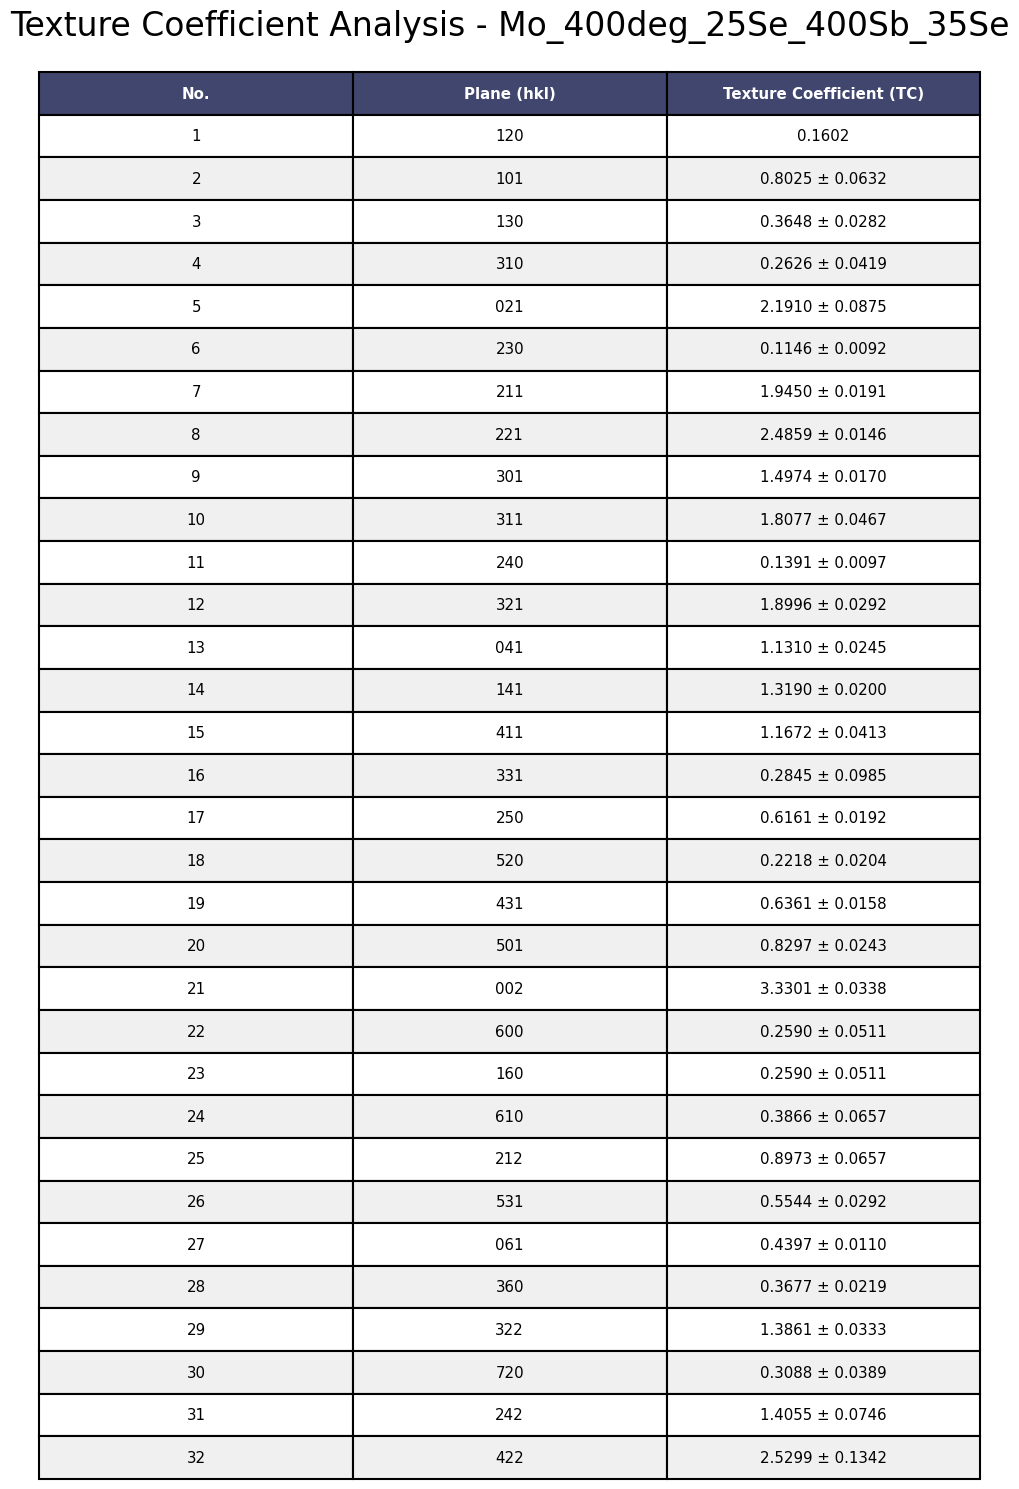

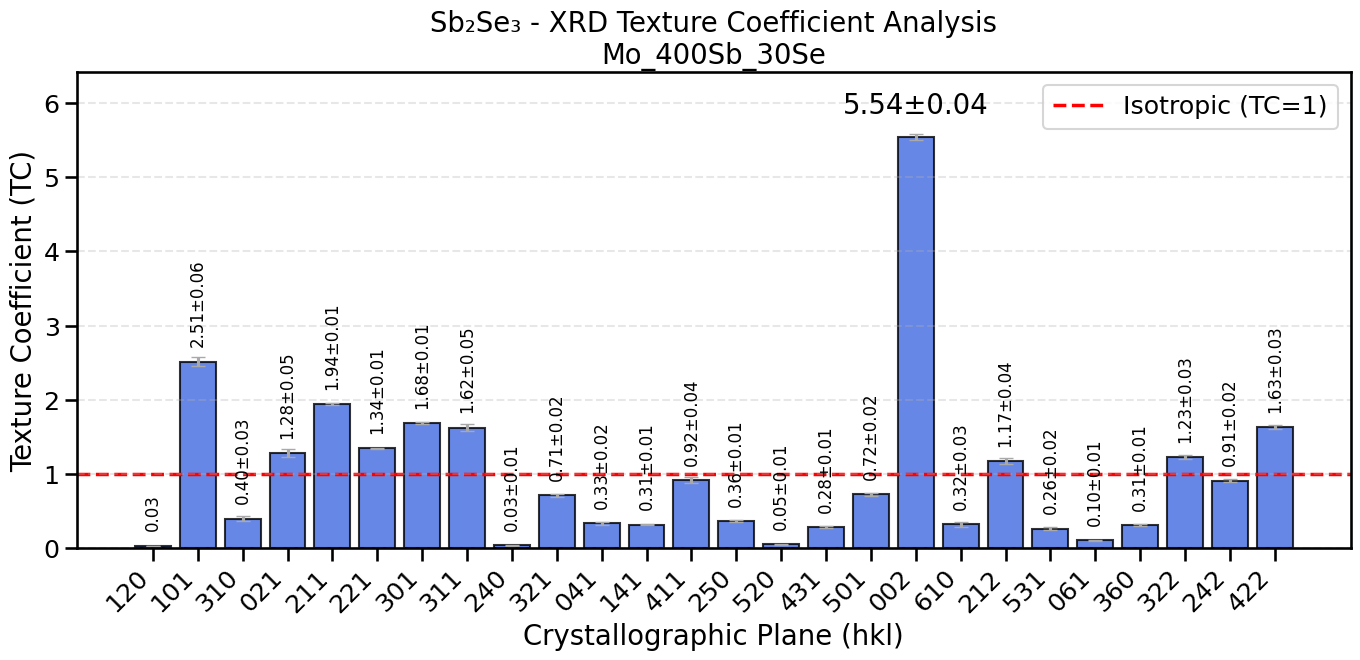

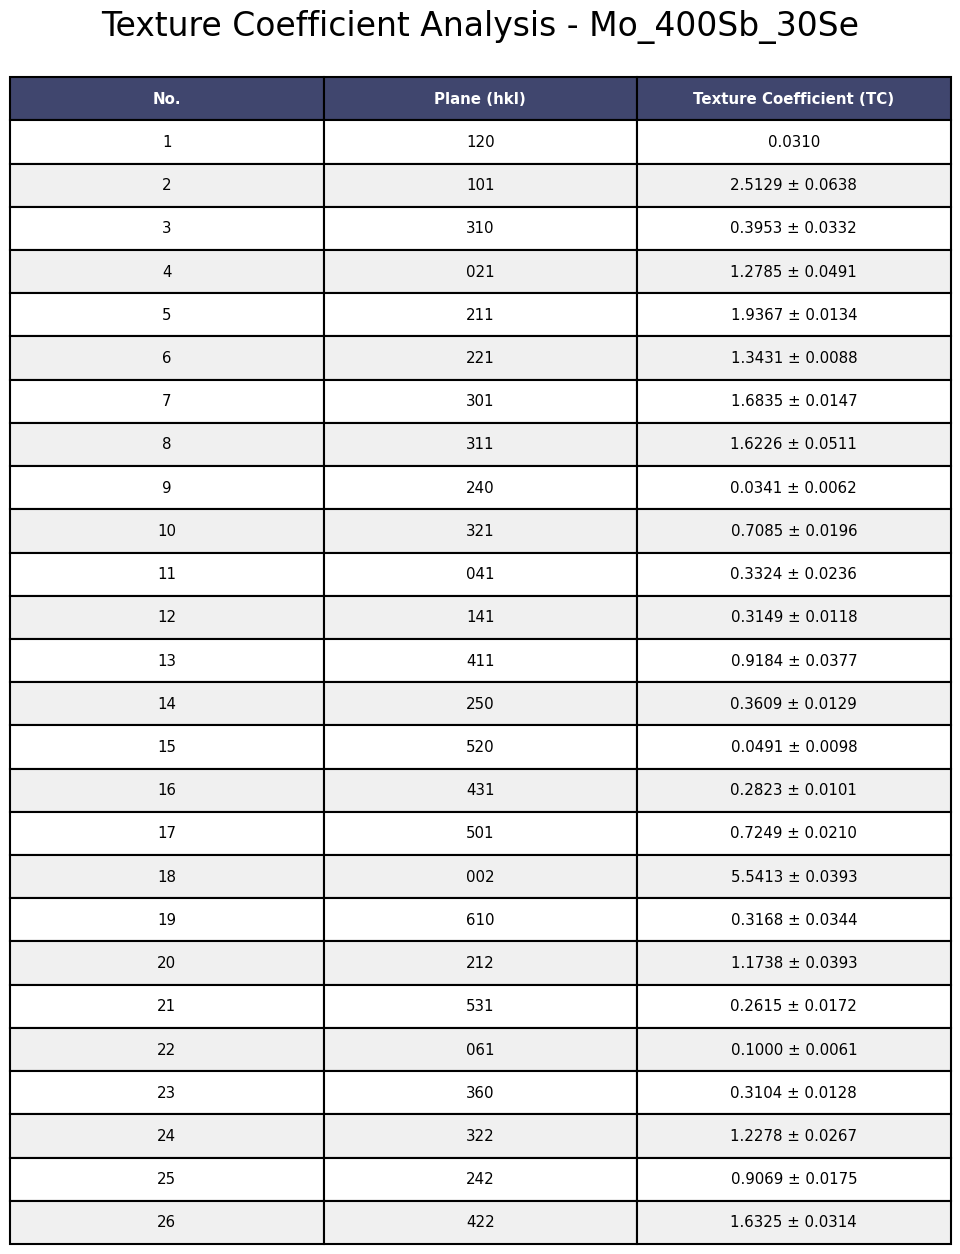

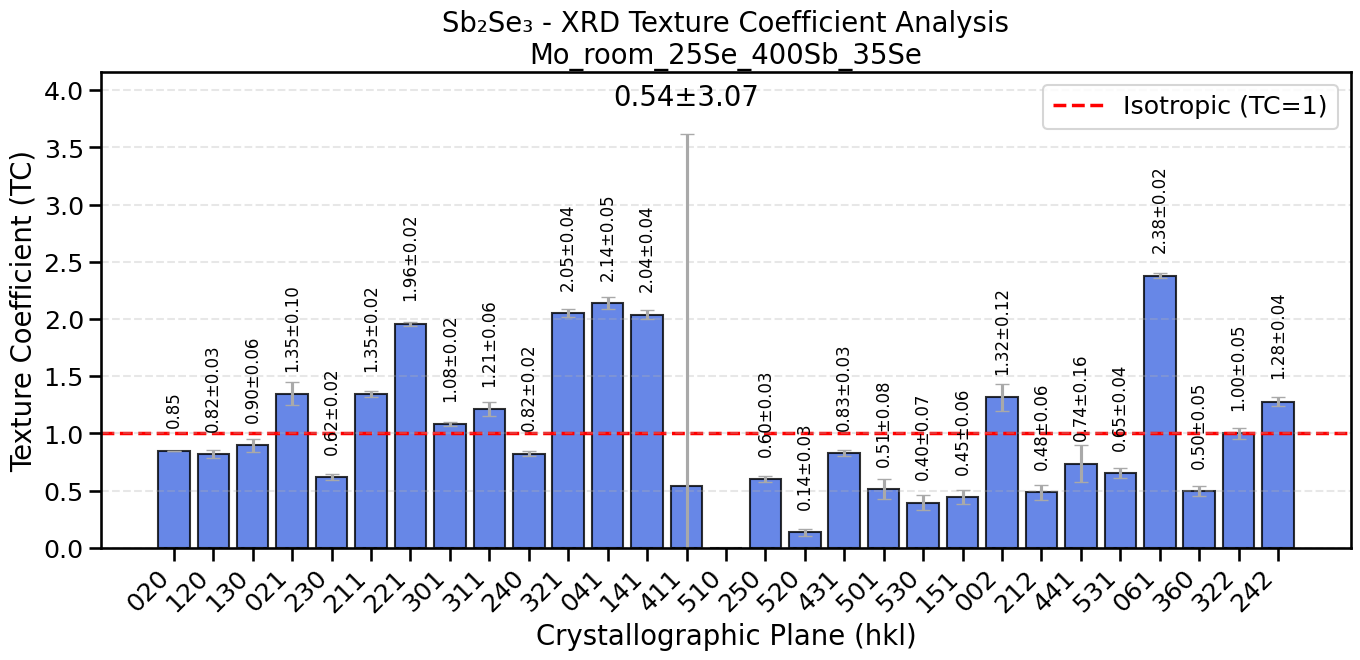

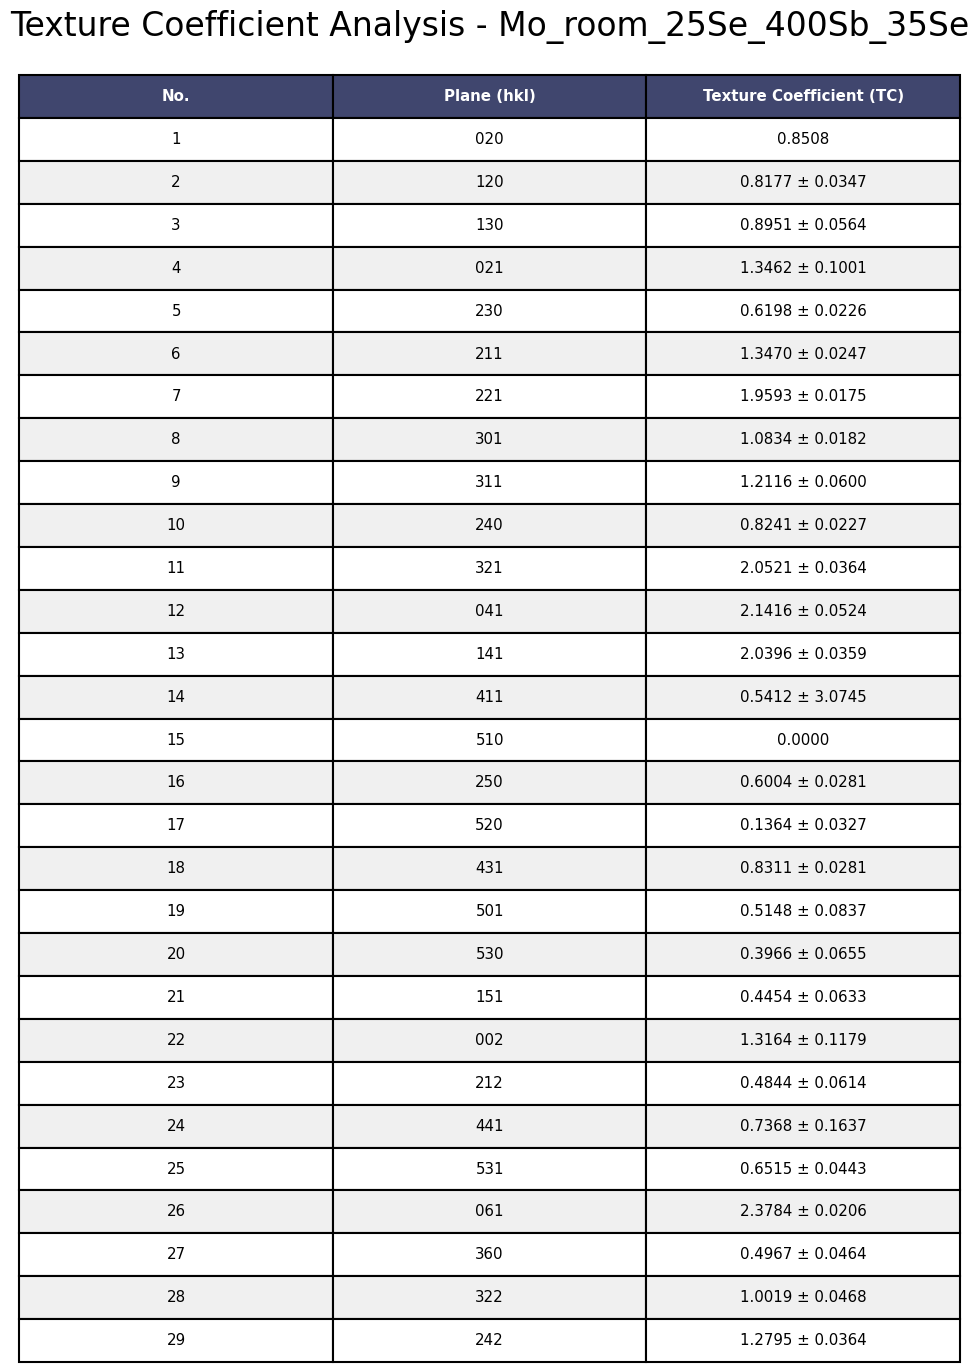


✓ Visualizations generated and saved


In [152]:
print("\n--- GENERATING VISUALIZATIONS ---")

import seaborn as sns
sns.set_context("talk", font_scale=1.1)

if not all_TC_results:
    print("✗ No texture coefficient results available to plot.")
else:
    # Build combined dataset for all samples
    combined_rows = []
    for filename, tc_result in all_TC_results.items():
        for hkl, tc, err in zip(tc_result['hkl'], tc_result['TC'], tc_result['TC_errors']):
            combined_rows.append({
                'Dataset': filename,
                'hkl': hkl,
                'TC': tc,
                'TC_Error': err
            })

    combined_df = pd.DataFrame(combined_rows)

    # Preserve the reference peak order when available
    reference_order = list(reference_card.keys()) if 'reference_card' in globals() else []
    unique_hkl = combined_df['hkl'].drop_duplicates().tolist()
    if reference_order:
        ordered_hkl = [hkl for hkl in reference_order if hkl in unique_hkl]
        ordered_hkl += [hkl for hkl in unique_hkl if hkl not in ordered_hkl]
        unique_hkl = ordered_hkl

    datasets = list(all_TC_results.keys())
    n_datasets = len(datasets)
    x = np.arange(len(unique_hkl))
    width = 0.8 / max(n_datasets, 1)

    fig, ax = plt.subplots(figsize=(max(12, len(unique_hkl) * 0.6), 7))

    for idx, dataset in enumerate(datasets):
        dataset_df = combined_df[combined_df['Dataset'] == dataset].set_index('hkl').reindex(unique_hkl)
        tc_values = dataset_df['TC'].fillna(np.nan).values
        tc_errors = dataset_df['TC_Error'].fillna(0).values
        positions = x - 0.4 + width / 2 + idx * width

        ax.bar(
            positions,
            tc_values,
            width,
            yerr=tc_errors,
            capsize=4,
            label=dataset,
            edgecolor='black',
            alpha=0.85,
        )

    #ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2.5, label='Isotropic (TC=1)', zorder=1) line at y = 1 (isotropic)
    ax.set_title('Sb₂Se₃ - Texture Coefficient Comparison', pad=20)
    ax.set_xlabel('Crystallographic Plane (hkl)')
    ax.set_ylabel('Texture Coefficient (TC)')
    ax.set_xticks(x)
    ax.set_xticklabels(unique_hkl, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
    ax.set_ylim(0, max((combined_df['TC'] + combined_df['TC_Error']).max() * 1.15, 1.2))
    plt.tight_layout()
    #plt.savefig('TC_comparison_all_samples.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Per-sample plots for detail
    for filename, tc_result in all_TC_results.items():
        hkl_labels = tc_result['hkl']
        TC_values = tc_result['TC']
        TC_errors = tc_result['TC_errors']

        fig1, ax1 = plt.subplots(figsize=(14, 7))
        bars = ax1.bar(
            range(len(hkl_labels)),
            TC_values,
            yerr=TC_errors,
            capsize=5,
            ecolor='darkgray',
            color='royalblue',
            edgecolor='black',
            alpha=0.8,
            linewidth=1.5,
        )

        ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=2.5, label='Isotropic (TC=1)', zorder=1)
        ax1.set_title(f'Sb₂Se₃ - XRD Texture Coefficient Analysis\n{filename}')
        ax1.set_xlabel('Crystallographic Plane (hkl)')
        ax1.set_ylabel('Texture Coefficient (TC)')
        ax1.set_xticks(range(len(hkl_labels)))
        ax1.set_xticklabels(hkl_labels, rotation=45, ha='right')
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        ax1.legend(loc='best')

        for i, (bar, tc_val, tc_err) in enumerate(zip(bars, TC_values, TC_errors)):
            height = bar.get_height()
            if height > 0.01:
                label_text = f'{tc_val:.2f}' if tc_err == 0 else f'{tc_val:.2f}±{tc_err:.2f}'
                if height + tc_err + 0.4 > ax1.get_ylim()[1]:
                    ax1.text(bar.get_x() + bar.get_width() / 2, height + tc_err + 0.2, label_text, ha='center', va='bottom')
                else:
                    ax1.text(bar.get_x() + bar.get_width() / 2, height + 0.2, label_text, ha='center', va='bottom', rotation=90, fontsize=12)

        ax1.set_ylim(0, max((TC_values + TC_errors).max() * 1.15, 1.2))
        plt.tight_layout()
        #plt.savefig(f'TC_chart_{filename}.png', dpi=300, bbox_inches='tight')
        plt.show()

        table_data = []
        for i, (hkl, tc, err) in enumerate(zip(hkl_labels, TC_values, TC_errors), 1):
            combined_val = f"{tc:.4f} ± {err:.4f}" if err > 0 else f"{tc:.4f}"
            table_data.append([i, hkl, combined_val])

        fig2, ax_table = plt.subplots(figsize=(10, len(table_data) * 0.4 + 2.5))
        ax_table.axis('tight')
        ax_table.axis('off')
        table = ax_table.table(
            cellText=table_data,
            colLabels=["No.", "Plane (hkl)", "Texture Coefficient (TC)"],
            cellLoc='center',
            loc='center',
            bbox=[0, 0, 1, 1],
        )
        table.scale(1, 2.2)
        for i in range(3):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')
        for i in range(1, len(table_data) + 1):
            for j in range(3):
                table[(i, j)].set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

        fig2.suptitle(f'Texture Coefficient Analysis - {filename}', y=0.98)
        plt.tight_layout()
        #plt.savefig(f'TC_table_{filename}.png', dpi=300, bbox_inches='tight')
        plt.show()

print("\n✓ Visualizations generated and saved")


--- GENERATING XRD SPECTRUM WITH JCPDS REFERENCE PEAKS ---


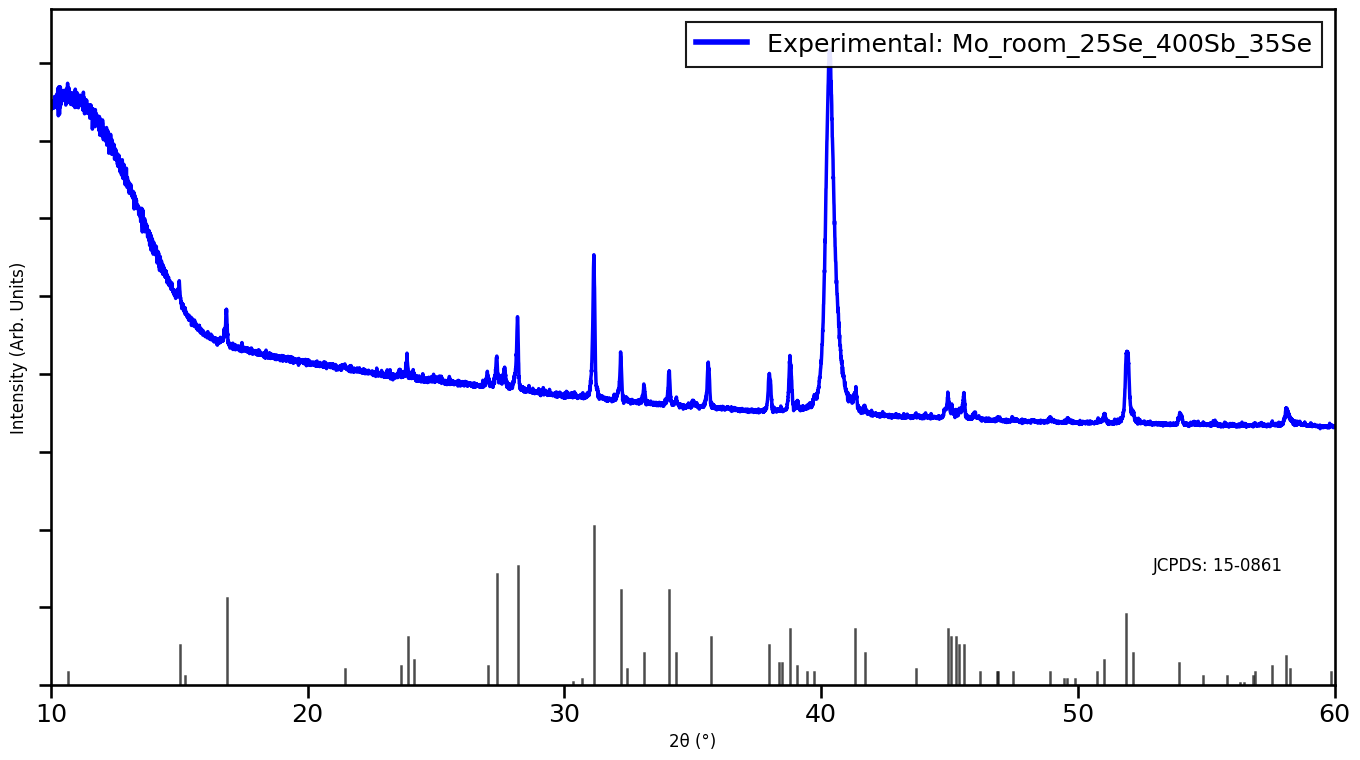

✓ XRD spectrum visualization generated for Mo_room_25Se_400Sb_35Se.ASC


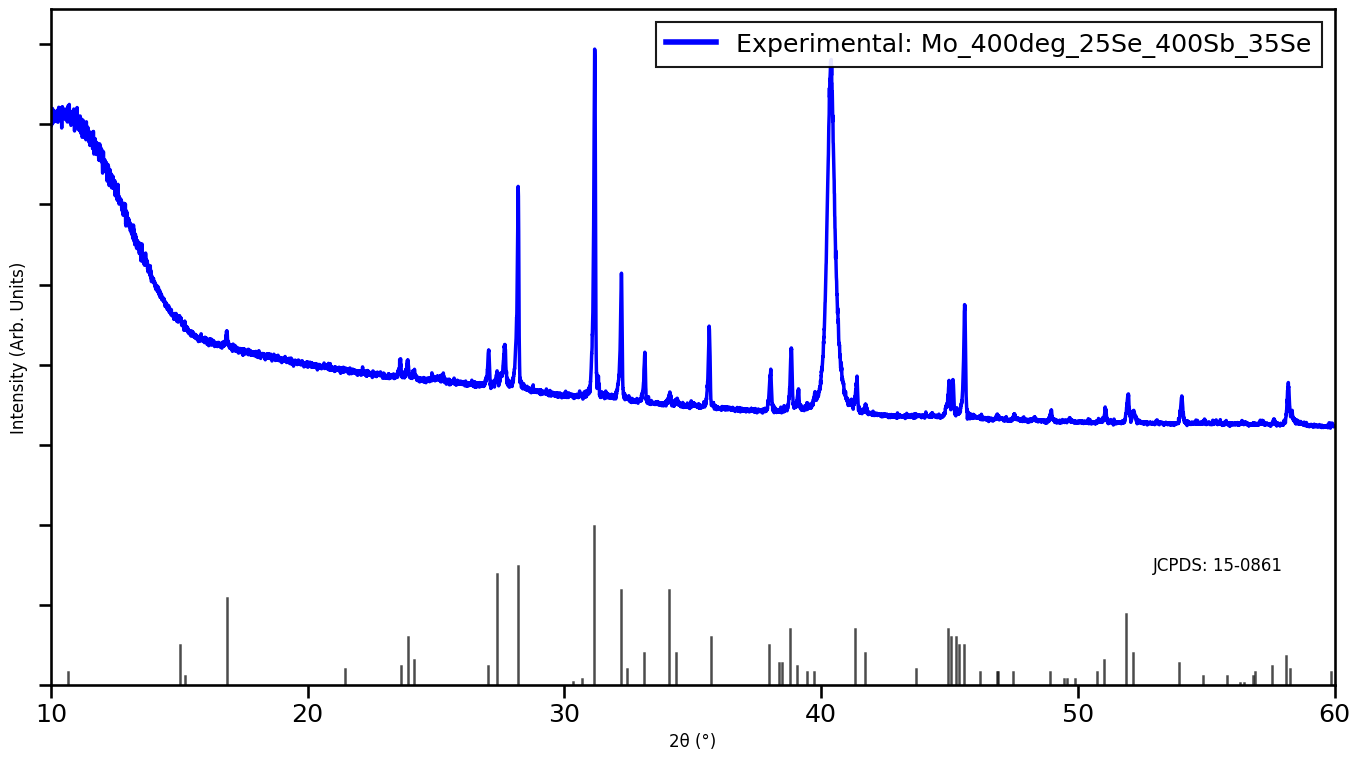

✓ XRD spectrum visualization generated for Mo_400deg_25Se_400Sb_35Se.ASC


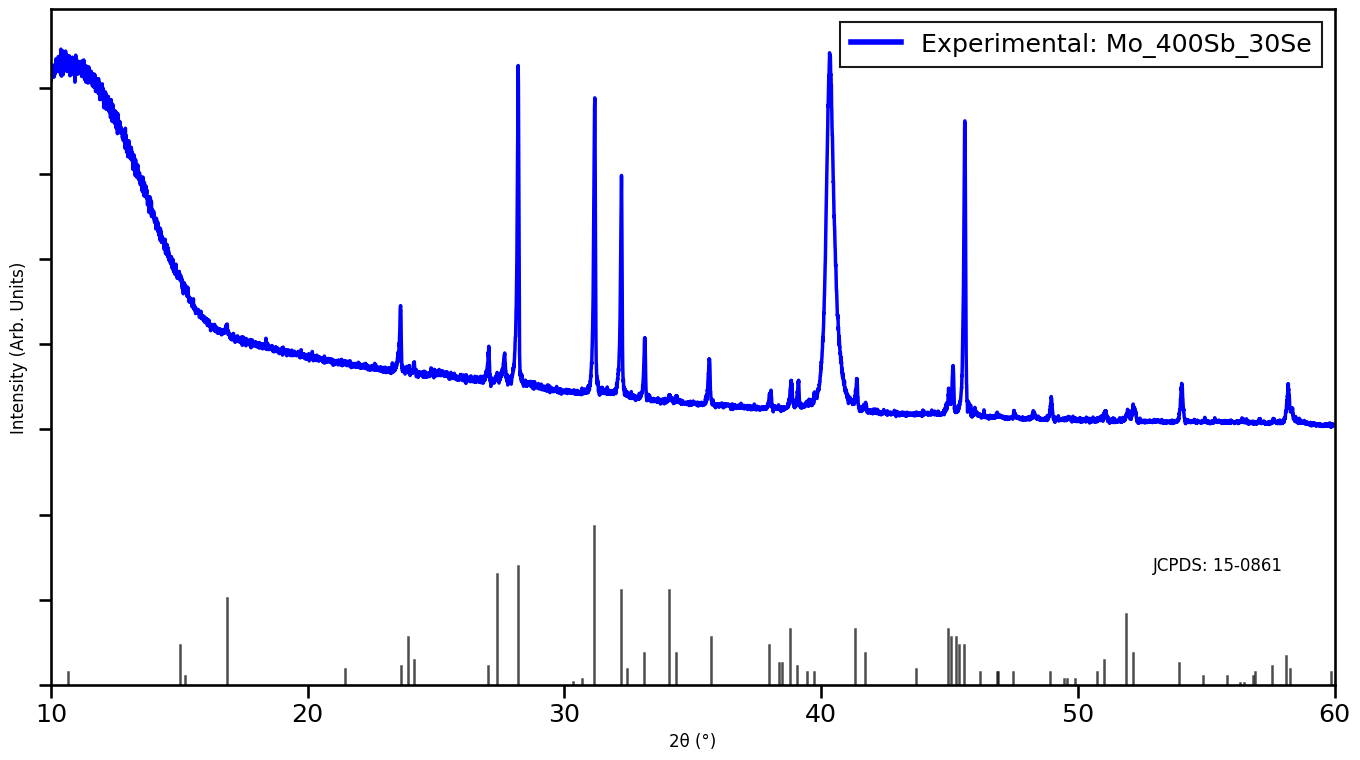

✓ XRD spectrum visualization generated for Mo_400Sb_30Se.ASC

✓ All XRD spectrum visualizations generated and saved

--- Generating overlay-stacked XRD plot (base + offset spectra) ---


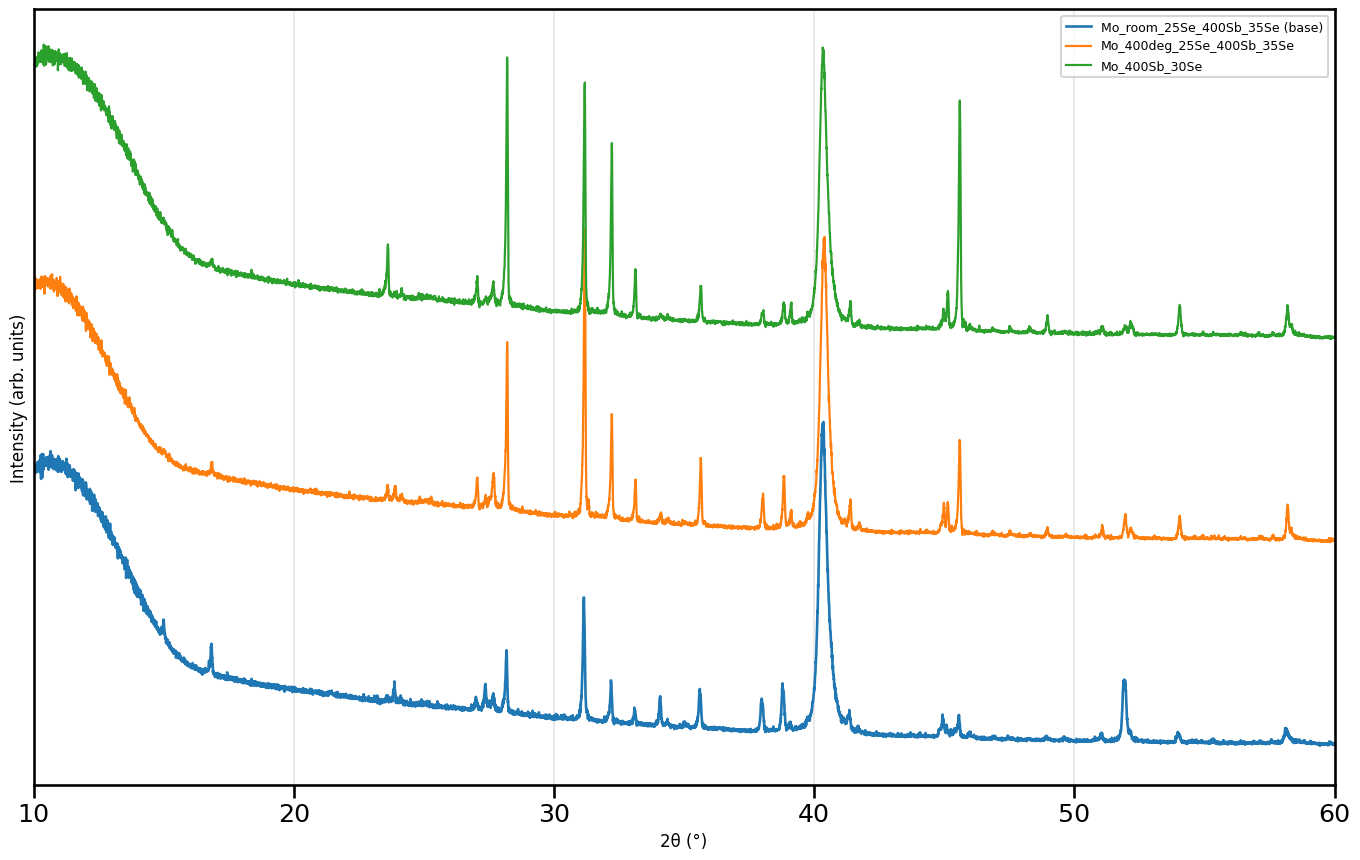

✓ Overlay-stacked XRD figure saved: XRD_overlay_starting_with_base.png


In [153]:
# ---------------------------------------------------------
# 3. VISUALIZATION: XRD SPECTRUM WITH JCPDS REFERENCE PATTERN
# ---------------------------------------------------------

print("\n--- GENERATING XRD SPECTRUM WITH JCPDS REFERENCE PEAKS ---")

# Create reference pattern from JCPDS data
theta_2_ref = [ref_data['2theta'] for ref_data in reference_card.values()]
intensity_ref = [ref_data['I0'] for ref_data in reference_card.values()]

# Plot for each spectrum
for name, theta_exp, intensity_exp in spectra:
    # Normalize reference intensities
    intensity_ref_normalized = np.array(intensity_ref) / np.max(intensity_ref) * np.max(intensity_exp) * 0.4
    
    # Calculate vertical offset for experimental spectrum
    offset_exp = np.max(intensity_ref_normalized) * 1.5
    
    # Create the XRD spectrum plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot reference pattern as vertical lines (at bottom, baseline)
    for i, (theta, intensity) in enumerate(zip(theta_2_ref, intensity_ref_normalized)):
        ax.plot([theta, theta], [0, intensity], 'k-', linewidth=1.8, alpha=0.7)
    
    # Plot experimental spectrum (upper, offset)
    ax.plot(theta_exp, intensity_exp + offset_exp, 'b-', linewidth=2.5)
    
    # Add "JCPDS: 15-0861" reference label
    ax.text(58, offset_exp * 0.5, 'JCPDS: 15-0861', color='black', ha='right', va='center', fontsize=12)
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='blue', lw=4, label=f'Experimental: {name.replace(".ASC", "")}')]
    legend = ax.legend(handles=legend_elements, loc='upper right', frameon=True, 
                       fancybox=False, edgecolor='black', framealpha=0.9)
    legend.get_frame().set_linewidth(1.5)
    
    # Labels and formatting
    ax.set_xlabel('2θ (°)', fontsize=12)
    ax.set_ylabel('Intensity (Arb. Units)', fontsize=12)
    ax.set_xlim(10, 60)
    ax.set_ylim(0, offset_exp + np.max(intensity_exp) * 1.1)
    
    # Remove y-axis tick labels
    ax.set_yticklabels([])
    
    # Remove grid
    ax.grid(False)
    
    # Close the axes (make all spines visible)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    
    # Improve layout
    plt.tight_layout()
    safe_name = name.replace('.ASC', '').replace(' ', '_')
    #plt.savefig(f'XRD_spectrum_{safe_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ XRD spectrum visualization generated for {name}")

print("\n✓ All XRD spectrum visualizations generated and saved")

# ---------------------------------------------------------
# Combined overlay-stacked XRD plot (start with a base spectrum)
# Stacks remaining spectra above the base with offsets and different colors
# ---------------------------------------------------------
try:
    if spectra:
        print('\n--- Generating overlay-stacked XRD plot (base + offset spectra) ---')

        # Choose base spectrum (start with the first one by default)
        base_idx = 0
        base_name, base_theta, base_intensity = spectra[base_idx]

        # Global max intensity for scaling offsets
        max_intensity_all = max([intensity.max() for name, theta, intensity in spectra])

        # Offset step between spectra (fraction of global max)
        offset_step = max_intensity_all * 0.6

        fig, ax = plt.subplots(figsize=(14, 9))

        # Generate distinct colors for each spectrum
        cmap = plt.cm.get_cmap('tab10')
        colors = [cmap(i % cmap.N) for i in range(len(spectra))]

        # Plot base spectrum without vertical offset
        ax.plot(base_theta, base_intensity, color=colors[base_idx], linewidth=1.9,
                label=f"{base_name.replace('.ASC', '')} (base)")

        # Plot other spectra stacked above the base
        for idx, (name, theta_exp, intensity_exp) in enumerate(spectra):
            if idx == base_idx:
                continue
            # Offset increases with the index to stack spectra upwards
            # Use (idx) so that order follows the spectra list
            offset = offset_step * idx
            ax.plot(theta_exp, intensity_exp + offset, color=colors[idx], linewidth=1.6,
                    label=f"{name.replace('.ASC', '')}")

        # Formatting
        ax.set_xlabel('2θ (°)', fontsize=12)
        ax.set_ylabel('Intensity (arb. units)', fontsize=12)
        ax.set_yticks([])
        ax.set_xlim(10, 60)
        ax.grid(True, alpha=0.25, axis='x')
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        plt.tight_layout()
        #plt.savefig('XRD_overlay_starting_with_base.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('✓ Overlay-stacked XRD figure saved: XRD_overlay_starting_with_base.png')
    else:
        print('No spectra available to create overlay-stacked plot.')
except Exception as e:
    print(f'Error while creating overlay-stacked plot: {e}')

In [154]:
# ---------------------------------------------------------
# 4. SUMMARY STATISTICS
# ---------------------------------------------------------

print("\n" + "="*90)
print(" " * 20 + "TEXTURE COEFFICIENT ANALYSIS - FINAL REPORT")
print("="*90)

summary_data = []

for filename, tc_result in all_TC_results.items():
    hkl_labels = tc_result['hkl']
    TC_values = tc_result['TC']
    TC_errors = tc_result['TC_errors']
    I_exp_raw = tc_result['I_exp_raw']
    I_exp_norm = tc_result['I_exp_norm']
    I_std = tc_result['I_std']
    
    print(f"\n{filename}")
    print("-" * 90)
    
    # General information
    print(f"Data Source: Excel File")
    print(f"Reference Database: JCPDS-15-0861 (Sb₂Se₃)")
    print(f"Number of matched peaks: {len(hkl_labels)}")
    print(f"Normalization Factor (R): {tc_result['average_denominator']:.4f}")
    
    # Statistics
    print(f"\n{'TEXTURE COEFFICIENT STATISTICS':-^90}")
    print(f"  Mean TC:                {TC_values.mean():.4f}")
    print(f"  Median TC:              {np.median(TC_values):.4f}")
    print(f"  Standard Deviation:     {TC_values.std():.4f}")
    print(f"  Minimum TC:             {TC_values.min():.4f} → Plane {hkl_labels[TC_values.argmin()]}")
    print(f"  Maximum TC:             {TC_values.max():.4f} → Plane {hkl_labels[TC_values.argmax()]}")
    print(f"  Variance:               {TC_values.var():.4f}")
    
    # Orientation analysis
    preferred = np.sum(TC_values > 1)
    suppressed = np.sum(TC_values < 1)
    isotropic = np.sum(np.abs(TC_values - 1) < 0.05)
    
    print(f"\n{'CRYSTAL ORIENTATION ANALYSIS':-^90}")
    print(f"  Preferred planes (TC > 1.0):      {preferred} planes")
    print(f"  Suppressed planes (TC < 1.0):     {suppressed} planes")
    print(f"  Nearly isotropic (|TC-1| < 0.05): {isotropic} planes")
    
    # Top preferred planes
    top_indices = np.argsort(TC_values)[-5:][::-1]
    print(f"\n{'TOP 5 PREFERRED PLANES':-^90}")
    for rank, idx in enumerate(top_indices, 1):
        hkl = hkl_labels[idx]
        tc = TC_values[idx]
        err = TC_errors[idx]
        i_exp = I_exp_raw[idx]
        i_norm = I_exp_norm[idx]
        i_ref = I_std[idx]
        print(f"  {rank}. {hkl:>4s}: TC = {tc:7.4f} ± {err:7.4f}   "
              f"(I_raw={i_exp:.0f}, I_norm={i_norm:.1f}, I_ref={i_ref:.1f})")
    
    # Bottom suppressed planes
    bottom_indices = np.argsort(TC_values)[:3]
    print(f"\n{'TOP 3 SUPPRESSED PLANES':-^90}")
    for rank, idx in enumerate(bottom_indices, 1):
        hkl = hkl_labels[idx]
        tc = TC_values[idx]
        err = TC_errors[idx]
        i_exp = I_exp_raw[idx]
        i_norm = I_exp_norm[idx]
        i_ref = I_std[idx]
        print(f"  {rank}. {hkl:>4s}: TC = {tc:7.4f} ± {err:7.4f}   "
              f"(I_raw={i_exp:.0f}, I_norm={i_norm:.1f}, I_ref={i_ref:.1f})")
    
    # Save detailed results
    results_df = pd.DataFrame({
        'Plane (hkl)': hkl_labels,
        'I_exp_raw': I_exp_raw,
        'I_exp_normalized': I_exp_norm,
        'I_reference': I_std,
        'I_ratio': I_exp_norm / I_std,
        'TC': TC_values,
        'TC_Error': TC_errors,
    })
    
    csv_filename = f'TC_results_{filename}.csv'
    results_df.to_csv(csv_filename, index=False)
    print(f"\n✓ Detailed results saved to: {csv_filename}")
    
    # Store summary
    summary_data.append({
        'Dataset': filename,
        'Data Source': 'Excel',
        'Matched Peaks': len(hkl_labels),
        'Mean TC': TC_values.mean(),
        'Std Dev': TC_values.std(),
        'Min TC': TC_values.min(),
        'Max TC': TC_values.max(),
        'R Factor': tc_result['average_denominator'],
        'Preferred': preferred,
        'Suppressed': suppressed
    })

# Create and save summary table
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print("\n" + "="*90)
    print("SUMMARY TABLE")
    print("="*90)
    print(summary_df.to_string(index=False))
    
    summary_df.to_csv('TC_summary_statistics.csv', index=False)
    print("\n✓ Summary statistics saved to: TC_summary_statistics.csv")
    print("\n" + "="*90)


                    TEXTURE COEFFICIENT ANALYSIS - FINAL REPORT

Mo_200Sb_25Se
------------------------------------------------------------------------------------------
Data Source: Excel File
Reference Database: JCPDS-15-0861 (Sb₂Se₃)
Number of matched peaks: 22
Normalization Factor (R): 0.5907

------------------------------TEXTURE COEFFICIENT STATISTICS------------------------------
  Mean TC:                1.0000
  Median TC:              0.7663
  Standard Deviation:     0.8387
  Minimum TC:             0.0709 → Plane 240
  Maximum TC:             4.1058 → Plane 002
  Variance:               0.7034

-------------------------------CRYSTAL ORIENTATION ANALYSIS-------------------------------
  Preferred planes (TC > 1.0):      9 planes
  Suppressed planes (TC < 1.0):     13 planes
  Nearly isotropic (|TC-1| < 0.05): 0 planes

----------------------------------TOP 5 PREFERRED PLANES----------------------------------
  1.  002: TC =  4.1058 ±  0.0545   (I_raw=1882, I_norm=60.6, I_ref